# Progetto 39: Minimum Stretch Spanning Tree Problem (MSSTP)

## Descrizione del problema
Dato un grafo $G$ completo e non orientato, con un costo $c^{ij}$ per ogni arco $(i,j)$, si calcoli l'albero di supporto $T^{*}$ tale che, definita con $D^{*}(ij)$ la distanza su $T^{*}$ fra $i$ e $j$, si minimizzi la massima differenza (al variare dell'arco $(i,j)$) fra $D^{*}(ij)$ e $c^{ij}$ (il costo per andare da $i$ a $j$ sull'albero e il costo per andare da $i$ a $j$ sul grafo usando l'arco $(i,j)$). 
Nota: se $(ij) \in T^{*}$ la differenza è 0. 

### Obiettivo
L'obiettivo è quinid minimizzare la discrepanza che l'albero introduce rispetto al grafo originale, ma solo rispetto agli archi che l'albero sacrifica (anche perchè con gli archi che riporta ovviamente la discrepanza non c'è). L'obiettivo diventa quindi quello di minimizzare il cammino critico all'interno dell'albero T* dato che questo è il diretto responsabile dello stretch massimo.
Per fare un esempio
In pratica è come se l'albero rappresentasse i collegamenti da realizzare tra diverse città per fornirgli la fibra ottica. Se consideriamo una mappa in cui ogni possibile città è collegata con tutte le altre e che ogni arco ha un costo, noi vogliamo scegliere un insieme di collegamenti che vada a minimizzare la massima discrepanza che c'è tra il collegamento di due città nella mappa che stiamo realizzando e quello tra le due città nella mappa completamente connessa.

---

## Modello Matematico
L'obiettivo è determinare un albero di supporto $T^*$ che minimizzi la massima differenza tra la distanza sull'albero e il costo dell'arco nel grafo originale. Il problema è ampiamente studiato in letteratura come MSSTP ed è classificato come NP-hard.

La funzione obiettivo da minimizzare è la seguente:

$$
Stretch(G, T) = \max_{(i,j) \in A} \{ D_T(i,j) - c_{ij} \}
$$
$$
T^* = \arg \min_{T \in \Theta(G)} \{ Stretch(G, T) \}
$$

Dove:
- $D_T(i,j)$ rappresenta la distanza tra i nodi $i$ e $j$ calcolata lungo l'unico cammino presente nell'albero $T$.
- $c_{ij}$ è il costo (o peso) dell'arco $(i,j)$ nel grafo originale $G$.
- $\Theta(G)$ è l'insieme di tutti i possibili alberi di copertura del grafo.
- Se un arco $(i,j)$ appartiene all'albero $T^*$, la differenza $D_{T^*}(i,j) - c_{ij}$ è pari a 0.
- Un cammino nell'albero è definito **critico** se la sua lunghezza determina il valore di stretch massimo della soluzione attuale.

---

## 1. Fase di Inizializzazione
L'obiettivo è partire con un albero di copertura valido. Puoi riutilizzare le euristiche descritte nello studio per garantire varietà:

- **Algoritmo**: Scegli casualmente tra Random_Kruskal, Random_Prim, Random_Dijkstra o Min-Weight BFS.
- **Input**: Il grafo originale $G$.
- **Output**: Una soluzione iniziale $S\_T$ e il calcolo del suo Stretch iniziale.

$$Stretch(G, S\_T) = \max_{\forall(u,w) \in A} D_{S\_T}(u,w)$$

dove $D_{S\_T}(u,w)$ è la distanza tra i nodi nell'albero.

---

## 2. Ciclo Principale: Meta-euristica SA
Il "cuore" del progetto gestisce l'esplorazione globale.

- **Parametri**: Imposta una Temperatura iniziale $T_{high}$, una Temperatura minima $T_{low}$ e un tasso di raffreddamento $\alpha$ (es. 0.95).
- **Mossa di Perturbazione (Diversificazione)**: Usa la $NBHD_1$ (Cycle Exchange) dello studio.
  - Aggiungi un arco casuale per creare un ciclo.
  - Rimuovi un arco diverso dal ciclo per tornare a un albero.
- **Criterio di Accettazione**:
  - Se $Stretch(S\_T_{new}) < Stretch(S\_T_{old})$, accetta sempre.
  - Se è peggiore, accetta con probabilità $P = e^{-\frac{\Delta Stretch}{T}}$.


---


## 3. Fase Ibrida: Intensificazione (Local Search)
Qui integri la potenza della ricerca locale dello studio. Invece di eseguire la Local Search a ogni passo (troppo lento), la attivi solo in casi specifici (es. ogni volta che il SA trova un nuovo record globale).

**Procedura di Local Search (Ispirata al B-VND dello studio):**
Quando il SA identifica una zona promettente, esegui un raffinamento chirurgico sui percorsi critici:

- **Identificazione**: Trova il percorso critico nell'albero attuale.
- **Ricostruzione ($NBHD_{2-6}$)**: Applica a rotazione le tecniche di ricostruzione dello studio per quel percorso:
  - Ricostruisci con Random Prim ($NBHD_2$).
  - Ricostruisci con Random Kruskal ($NBHD_3$).
  - Ricostruisci con Random Dijkstra ($NBHD_4$).
  - Ricostruisci con Max Degree BFS ($NBHD_5$).
- **Miglioramento**: Se la ricostruzione riduce lo stretch, aggiorna la soluzione e continua a rifinire finché non trovi più miglioramenti (minimo locale).

### Fase 0: Caricamento delle Istanze TSPLIB (Grafi Completi e Pesati)
Come da definizione del problema MSSTP, lavoriamo con **grafi completi e pesati**, dove il costo $c^{ij}$ è associato a ciascun arco. Per questo motivo, invece di usare istanze topologiche come le Harwell-Boeing, utilizziamo le istanze del **Symmetric TSP (TSPLIB95)**, che forniscono matrici di distanze complete o coordinate spaziali da cui derivare distanze euclidee.

I file delle istanze in formato compresso (`.tsp.gz`) si trovano già nella directory `data/ALL_tsp/`.
In questa cella ci occupiamo di esplorare la directory, estrarre i file necessari e preparare il terreno per il caricamento in memoria. Utilizzeremo la libreria `tsplib95` per effettuare il parsing agevolmente.

In [39]:
import os
import gzip
import shutil

# Directory dei dati
data_dir = os.path.join("data", "ALL_tsp")
extracted_dir = os.path.join("data", "extracted_tsp") # metto in una cartella tutte le istanze che estraggo dall'archivio compresso scaricato
os.makedirs(extracted_dir, exist_ok=True)

# Elenco di tutti i file di istanze disponibili
all_files = [f for f in os.listdir(data_dir) if f.endswith('.tsp.gz')]
print(f"Trovate {len(all_files)} istanze TSP compresse nella cartella '{data_dir}'.\n")

def extract_instance(filename):
    """Estrae l'istanza e restituisce il percorso al file estratto."""
    gz_path = os.path.join(data_dir, filename)
    base_name = filename[:-3] # nome del file senza i caratteri ".gz"
    extracted_path = os.path.join(extracted_dir, base_name)
    
    if not os.path.exists(extracted_path):
        with gzip.open(gz_path, 'rb') as f_in:
            with open(extracted_path, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print(f"Estratto: {base_name}")
    return extracted_path

# Scegliamo un piccolo sottoinsieme di istanze note per testare l'algoritmo rapidamente
test_instances = ['berlin52.tsp.gz', 'att48.tsp.gz', 'eil51.tsp.gz', 'kroA100.tsp.gz', 'gr17.tsp.gz', 'ulysses16.tsp.gz'] # aggiungo ulysses16.tsp.gz per avere un'istanza molto piccola da testare velocemente

print("Preparazione delle istanze di test in corso...")
test_paths = []
for inst in test_instances:
    if inst in all_files:
        path = extract_instance(inst)
        test_paths.append(path)
        print(f"✓ Istanza pronta: {path}")
    else:
        print(f"✗ Istanza {inst} non trovata.")

print("\nFase di estrazione e rilevamento completata.")


Trovate 111 istanze TSP compresse nella cartella 'data/ALL_tsp'.

Preparazione delle istanze di test in corso...
✓ Istanza pronta: data/extracted_tsp/berlin52.tsp
✓ Istanza pronta: data/extracted_tsp/att48.tsp
✓ Istanza pronta: data/extracted_tsp/eil51.tsp
✓ Istanza pronta: data/extracted_tsp/kroA100.tsp
✓ Istanza pronta: data/extracted_tsp/gr17.tsp
Estratto: ulysses16.tsp
✓ Istanza pronta: data/extracted_tsp/ulysses16.tsp

Fase di estrazione e rilevamento completata.


## Parsing dei dati e funzioni core (utilities)

### TSPLIB95
Per gestire in maniera consona le istanze del problema scaricate usiamo le funzioni rese disponibili dalla libreria TSPLIB95 che è stata sviluppata appositamente per le istanze della libreria pubblica TSPLIB, da cui sono stati scaricati i file dei grafi.


Tra le feature principali ci sono:
- quella per convertire automaticamente le istanze in networkx.Graph instances, libreria usata per la gestione dei grafi e degli alberi all'interno del progetto.  
- quella che fornisce la possibilità di customizzare tutti i campi e i problemi dichiarati data la naturale compatibilità dello strumento con la risorsa dei problemi.



### NetworkX
Libreria standard nel settore che utilizzerò per gestire i grafi e tutte le funzioni ad essi associate

La sua funzione minimum_spanning_tree consente di trovare il minimum spanning tree di un grafo utilizzando un determinato algoritmo che possiamo anche specificare tramite il parametro algorithm

In [30]:
import tsplib95
import networkx as nx

def load_tsp_as_graph(filepath):
    """
    Legge un'istanza TSPLIB e restituisce un grafo completo nx.Graph.
    I nodi sono interi (0-indexed). I pesi degli archi sono i costi c_ij.
    """
    problem = tsplib95.load(filepath)
    G = problem.get_graph()
    G_zero_indexed = nx.convert_node_labels_to_integers(G, first_label=0) # Facciamo partire l'indicizzazione dei nodi da 0 invece che da 1 (standard di TSPLIB)
    return G_zero_indexed
    # OSS la modifica dell'indice è utile per evitare di fare continui aggiustamenti nella manipolazione delle etichette tramite vettori o matrici


def compute_stretch(G, T):
    """
    Calcola lo stretch: max_{i,j} ( D_T(i,j) - c_ij )
    """
    all_dist_T = dict(nx.all_pairs_dijkstra_path_length(T, weight='weight')) # Attraverso l'algoritmo di Dijkstra calcola la distanza tra ogni possibile coppia di nodi all'interno dell'albero
                                                                             # Il risultato è un dizionario di dizionari --> all_dist_T[u][v] = lunghezza dell'unico cammino che collega u e v sull'albero T
    max_stretch = -float('inf') # inizializzo lo stretch massimo con il valore di - infinito
    for u, v, data in G.edges(data=True):
        c_uv = data.get('weight', 0) # inizializzazione del costo dell'arco che va da u a v
        dist_T = all_dist_T[u][v]
        stretch = dist_T - c_uv
        if stretch > max_stretch:
            max_stretch = stretch
    return max_stretch


def get_critical_paths(G, T):
    """
    Restituisce i percorsi in T che causano lo stretch massimo.
    """
    all_dist_T = dict(nx.all_pairs_dijkstra_path_length(T, weight='weight')) # stesso calcolo di compute_stretch
    max_stretch = -float('inf')
    critical_pairs = []
    
    for u, v, data in G.edges(data=True):
        c_uv = data.get('weight', 0)
        dist_T = all_dist_T[u][v]
        stretch = dist_T - c_uv
        if stretch > max_stretch:
            max_stretch = stretch
            critical_pairs = [(u, v)]
        elif stretch == max_stretch:    # se troviamo un altro cammino con lo stesso stretch
            critical_pairs.append((u, v))
            
    paths = []
    for u, v in critical_pairs:
        path = nx.shortest_path(T, source=u, target=v, weight='weight') # funzione che restituisce il cammino critico tra u e v sull'albero T
        paths.append((u, v, path)) # lista dei cammini critici
    return max_stretch, paths


## Visualizzazione del grafo dell'istanza scelta

Usiamo questa semplice cella per la visualizzazione del grafo dell'istanza selezionata per l'esecuzione dell'algoritmo

[!] Coordinate non valide rilevate, sto creando spring_layout...


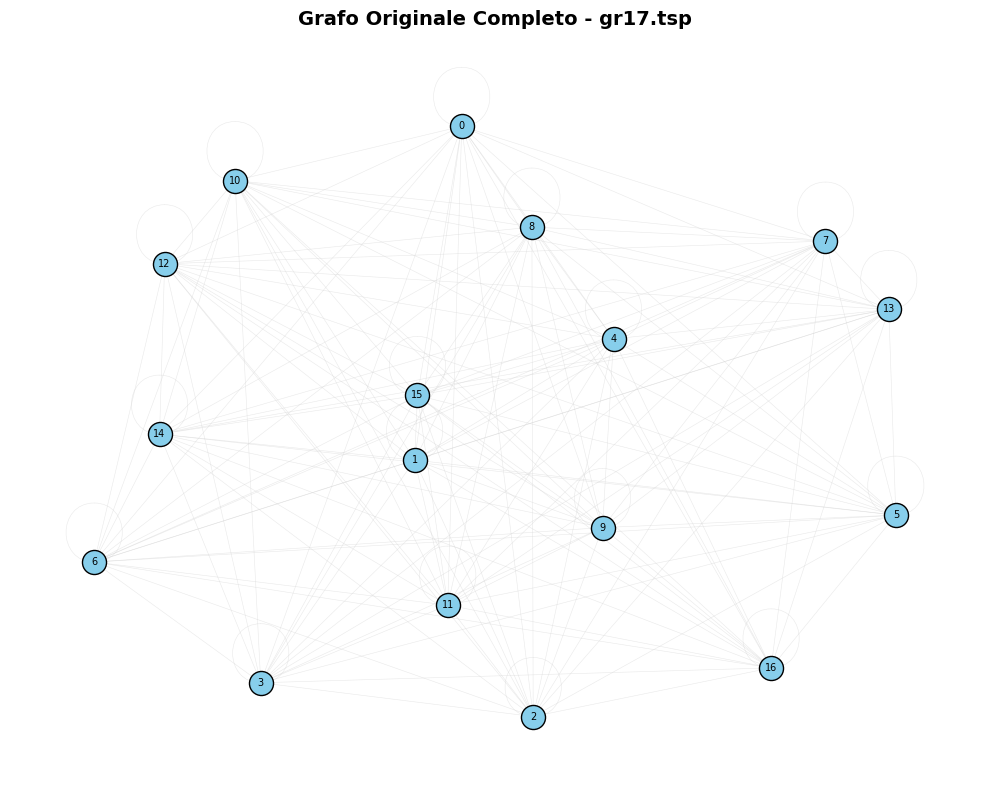

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd # Per una visualizzazione tabellare ordinata
import numpy as np

def validate_and_fix_pos(pos, G):
    """
    Valida che pos sia un dizionario con valori (x, y) validi.
    Se contiene valori non bidimensionali, cerca di correggerli o ricrea il layout.
    """
    if not isinstance(pos, dict):
        print(f"[!] pos non è un dizionario, sto creando spring_layout...")
        return nx.spring_layout(G, seed=42)
    
    # Verifica che tutti i nodi abbiano coordinate valide
    valid = True
    for node, coords in pos.items():
        if coords is None:
            valid = False
            break
        # Converti in array e controlla la dimensione
        try:
            arr = np.array(coords, dtype=float)
            if arr.ndim != 1 or len(arr) != 2:
                valid = False
                break
        except (ValueError, TypeError):
            valid = False
            break
    
    if not valid:
        print(f"[!] Coordinate non valide rilevate, sto creando spring_layout...")
        return nx.spring_layout(G, seed=42)
    
    # Converti tutti i valori a tuple (x, y) per sicurezza
    pos_fixed = {}
    for node, coords in pos.items():
        arr = np.array(coords, dtype=float).flatten()
        pos_fixed[node] = tuple(arr[:2])
    
    return pos_fixed

def plot_original_graph(G, pos, title="Grafo Originale Completo"):
    # Valida e correggi pos
    pos = validate_and_fix_pos(pos, G)
    
    plt.figure(figsize=(10, 8))
    plt.title(title, fontsize=14, fontweight='bold')
    nx.draw_networkx_nodes(G, pos, node_color='#87CEEB', node_size=300, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=7)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=0.4, alpha=0.5)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Esecuzione ---
instance_name = 'gr17.tsp'
path_inst = os.path.join("data", "extracted_tsp", instance_name)

if os.path.exists(path_inst):
    G_test = load_tsp_as_graph(path_inst)
    node_coords = nx.get_node_attributes(G_test, 'coord')
    
    # Se non ci sono coordinate o sono malformate, usa spring_layout
    # OSS è semplicemente per la visualizzazione, se non ci sono memorizzate le coordinate dei nodi questi vengono posizionai in modo casuale da spring_layout che impone che essi tra loro si respingano e gli archi
    # siano ciò che li tiene insieme
    if not node_coords:
        print(f"[!] Nessuna coordinata trovata, uso spring_layout...")
        pos = nx.spring_layout(G_test, seed=42)
    else:
        pos = node_coords
    
    # Valida e correggi le coordinate
    pos = validate_and_fix_pos(pos, G_test)
    
    # 1. Plot Grafo Originale
    plot_original_graph(G_test, pos, title=f"Grafo Originale Completo - {instance_name}")
else:
    print(f"[!] Errore: l'istanza {instance_name} non è stata trovata.")

## Euristiche costruttive

Questa cella va ad implementare le 4 euristiche selezionate per il problema preso in esame.

### Random Kruskal
Variante randomizzata del Kruskal per il calcolo del Minimum Spanning Tree che, invece di scegliere sempre l'arco in assoluto più economico (approccio puramente greedy), introduce una componente stocastica tipica delle procedure GRASP (Greedy Randomized Adaptive Search Procedure).

### Random Prim
Costruisce l'albero in maniera differente: il suo comportamento è assimilabile a quello di un incendio che si espande o una pianta che cresce (parte da un nodo e aggiunge rami uno alla volta finchè non ha coperto tutto il grafo)

### Random Dijkstra
A differenza dei precedenti questo algoritmo si concentra sulla minimizzazzione della distanza accumulata da un nodo radice tuttavia, usando la versione randomizzata, non otterremo lo Shortest Path Tree come risultato ma una sua variante diversificata dall'elemento della casualità.


Lo scopo è generare una soluzione iniziale con ognuna delle 4 e partire usando direttamente la migliore.  
Gli algoritmi verranno poi sfruttati all'interno della local search anche per apportare le modifiche agli alberi.

### Domande
- E' opportuno aumentare rlc o comunque cambiare la sua formulazione permettendogli di prendere ad esempio tutti gli archi che costano massimo il 10% in più di quello più economico possibile?

In [32]:
import random

def random_kruskal(G, rcl_size=3):
    """Random Kruskal: seleziona casualmente tra i primi 'rcl_size' archi più economici."""
    T = nx.Graph() # inizializziamo un nuovo grafo che conterrà l'albero finale
    T.add_nodes_from(G.nodes(data=True)) # mettiamo nel grafo tutti i nodi ma nessun arco
    edges = sorted(G.edges(data=True), key=lambda x: x[2].get('weight', float('inf'))) # ordino gli archi del grafo per peso crescente
    uf = nx.utils.UnionFind() # crea una struttura di tipo Union-find all'interno della quale  si tiene traccia di quali nodi sono stati collegati tra loro (come a formare un unico arcipelago)
                              # uf[e[0]] == uf[e[1]] = "il nodo A e il nodo B appartengono a un unico arcipelago?"
                              # se la risposta è si quei due nodi sono collegati e aggiungenfo un arco creerei un ciclo
                              # se la risposta è no i due nodi non sono collegati e l'arco servirebbe ad unirli

    while (len(T.edges) < len(G.nodes) - 1) and edges: # fino a quando l'albero non è completo (cioè ha N-1 archi dove N è il numero di nodi) e la lista non è vuota (caso che potrebbe verificarsi considerando un grafo non completamente connesso)
        candidates = []
        for e in edges: # scorro i vari archi
            if uf[e[0]] != uf[e[1]]: # se l'arco preso in considerazione non forma un ciclo
                candidates.append(e)
                if len(candidates) >= rcl_size:
                    break
        if not candidates:
            break
        chosen_edge = random.choice(candidates) # tra i candidati ne scelgo uno a caso
        edges.remove(chosen_edge) # rimuovo dalla lista degli archi di G quello scelto
        uf.union(chosen_edge[0], chosen_edge[1]) # registro l'arco tra i due nodi specificati nella struttura union-find (uf)
        T.add_edge(chosen_edge[0], chosen_edge[1], **chosen_edge[2]) # aggiunge anche l'arco al nostro albero copiando le proprietà dell'arco originale nel nuovo albero T
    return T

# OSS per ordinare gli archi ho semplicemente definito una lambda expression dove x rappresenta una tupla (u, v, attr_dict), prendiamo il dizionario degli
#     attributi di quella tupla x[2] e ci facciamo restituire il valore associato alla chiave 'weight', se questo non esiste restituiamo infinito (in modo che l'arco vada alla fine della lista)


def random_prim(G, rcl_size=3):
    """Random Prim: espande l'albero scegliendo casualmente tra i primi 'rcl_size' archi di frontiera più economici."""
    T = nx.Graph()
    T.add_nodes_from(G.nodes(data=True))
    nodes = list(G.nodes)
    unvisited = set(nodes)  # nodi non visitati salvati in una struttura set
    start_node = random.choice(nodes)
    visited = {start_node}
    unvisited.remove(start_node)
    
    while unvisited: # fino a quando ci sono nodi fuori dall'albero
        frontier_edges = []
        for u in visited:
            for v in unvisited:
                if G.has_edge(u, v):
                    frontier_edges.append((u, v, G[u][v]))  # aggiungo tutti gli archi dei nodi alla frontiera (nodi visitati collegati con quelli non visitati)
        
        frontier_edges.sort(key=lambda x: x[2].get('weight', float('inf'))) # ordino l'insieme secondo l'attributo weight
        chosen = random.choice(frontier_edges[:rcl_size])   # scelgo casualmente uno dei primi rcl_size elementi
        visited.add(chosen[1])
        unvisited.remove(chosen[1])
        T.add_edge(chosen[0], chosen[1], **chosen[2])
    return T



def random_dijkstra(G, rcl_size=3):
    """Random Dijkstra: a ogni passo sceglie uno dei 'rcl_size' nodi con distanza tentativa minima."""
    T = nx.Graph()
    T.add_nodes_from(G.nodes(data=True))
    start_node = random.choice(list(G.nodes))
    
    distances = {n: float('inf') for n in G.nodes}  # tabella all'interno della quale ogni nodo è a distanza infinita da quello scelto coem start_node
    distances[start_node] = 0
    parents = {start_node: None}
    unvisited = set(G.nodes)
    
    while unvisited:
        available = [n for n in unvisited if distances[n] != float('inf')]  # nodi pronti per essere espansi
        if not available:
            break
        available.sort(key=lambda x: distances[x])  # ordina i nodi available per distanza crescente dalla radice
        u = random.choice(available[:rcl_size]) # ne seleziona uno a caso tra i primi rcl_size
        unvisited.remove(u) # il nodo estratto viene rimosso da quelli non visitati
        
        if parents[u] is not None:
            T.add_edge(parents[u], u, weight=G[parents[u]][u].get('weight', 0))
            
        for v in G.neighbors(u):    # per ogni vicino v di u
            if v in unvisited:
                alt = distances[u] + G[u][v].get('weight', 0)   # calcoliamo una via alternativa 
                if alt < distances[v]:  # se la nuova via ha un costo minore
                    distances[v] = alt  # aggiorniamo la distanza di v da u
                    parents[v] = u  # diciamo che per raggiungere v passiamo per u
    return T



def random_bfs(G, max_branching=3):
    """Random Min-Weight BFS: per evitare un grafo a stella su grafi completi, espande casualmente fino a 'max_branching' nodi tra i più vicini."""
    T = nx.Graph()
    T.add_nodes_from(G.nodes(data=True))
    unvisited = set(G.nodes)
    start_node = random.choice(list(G.nodes))
    queue = [start_node]    # coda fifo che decide l'ordine di esplorazione --> il primo che entra è anche il primo che espande i suoi vicini
    unvisited.remove(start_node)
    
    while queue and unvisited:
        u = queue.pop(0)    # rimuovo il primo elemento della lista
        neighbors = []
        for v in unvisited:
            if G.has_edge(u, v):
                neighbors.append((v, G[u][v].get('weight', float('inf'))))  # prendiamo tutti i vicini non ancora visitati del nodo u che stiamo considerando
        neighbors.sort(key=lambda x: x[1])  # ordiniamo i vicini secondo il criterio di peso crescente
        
        pool_size = min(len(neighbors), max_branching * 2)
        if pool_size == 0: continue
        k = random.randint(1, min(len(neighbors), max_branching))   # k = numero casuale di figli da assegnare a questo nodo
        chosen = random.sample(neighbors[:pool_size], k)    # estraiamo k vicini dal pool
        
        for v, weight in chosen:
            if v in unvisited:  # se il nodo non era visitato
                unvisited.remove(v) # lo rimuovo dai non visitati
                T.add_edge(u, v, weight=weight) # lo aggiungo all'albero
                queue.append(v) # lo aggiungo alla coda in modo che venga espanso
                
        # Se la coda si svuota ma ci sono ancora nodi non visitati (grafo disconnesso o branching troppo limitato)
        # --> l'algoritmo sceglie un nodo a caso e lo connette forzatamente a un nodo già visitato per garantire che l'albero sia completo
        if not queue and unvisited:
            v = random.choice(list(unvisited))
            visited = list(set(G.nodes) - unvisited)
            if visited:
                u = random.choice(visited)
                unvisited.remove(v)
                T.add_edge(u, v, weight=G[u][v].get('weight', 0))
                queue.append(v)
            
    return T

def generate_initial_solution(G, method='random', rcl_size=3):
    """Genera una soluzione iniziale usando una delle euristiche costruttive."""
    methods = {
        'kruskal': random_kruskal,
        'prim': random_prim,
        'dijkstra': random_dijkstra,
        'bfs': lambda graph, rcl: random_bfs(graph, max_branching=rcl)
    }
    if method == 'random':
        method = random.choice(list(methods.keys()))
    
    if method not in methods:
        raise ValueError(f"Metodo {method} non supportato.")
        
    T = methods[method](G, rcl_size)
    stretch = compute_stretch(G, T)
    return T, stretch, method

# --- TEST delle Euristiche --- #
if 'G_test' in locals():
    print("\n--- Test Euristiche Costruttive su", instance_name, "---")
    best_st = float('inf')
    best_T = None
    best_m = None
    for m in ['kruskal', 'prim', 'dijkstra', 'bfs']:
        T_init, st_init, m_used = generate_initial_solution(G_test, method=m, rcl_size=3)   # calcola una soluzione con tutte e 4 le euristiche
        print(f"Metodo: {m_used.upper():<10} | Stretch Iniziale: {round(st_init, 2)}")
        if st_init < best_st:   # se lo stretch dell'euristica corrente è < di quello migliore finora trovato
            best_st = st_init   # aggiorno il valore dello stretch migliore
            best_T = T_init     # salvo l'albero
            best_m = m_used     # salvo il metodo migliore
            
    print(f"\nMiglior metodo: {best_m.upper()} con stretch {round(best_st, 2)}")



--- Test Euristiche Costruttive su gr17.tsp ---
Metodo: KRUSKAL    | Stretch Iniziale: 361
Metodo: PRIM       | Stretch Iniziale: 723
Metodo: DIJKSTRA   | Stretch Iniziale: 927
Metodo: BFS        | Stretch Iniziale: 1140

Miglior metodo: KRUSKAL con stretch 361


## Visualizzazione dello Spanning tree generato

[!] Coordinate non valide rilevate, sto creando spring_layout...


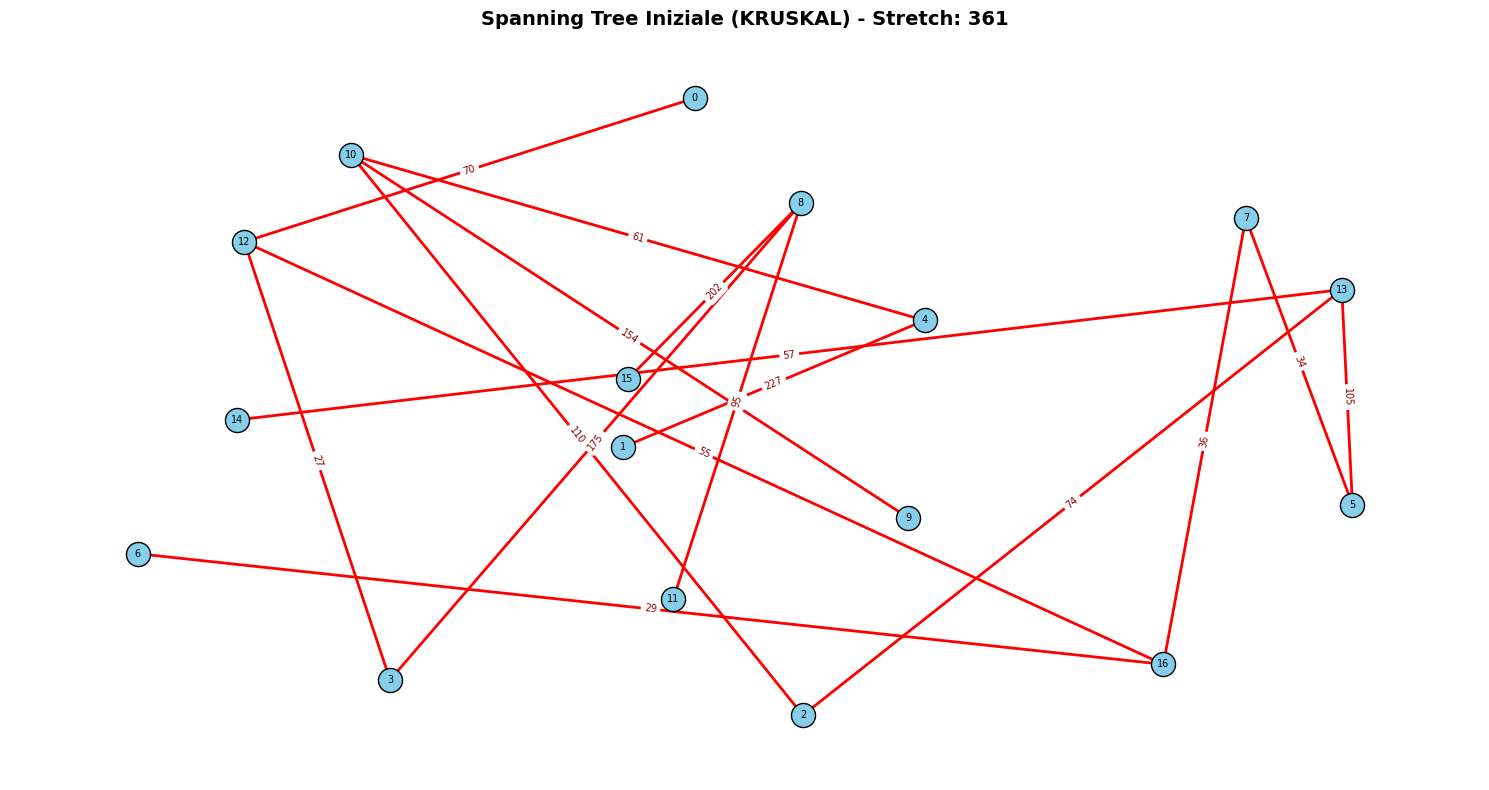


--- Analisi Dettagliata dello Stretch (Top 10 cammini critici) ---
Arco (u, v)  Costo Grafo (c_ij)  Distanza Albero (D_T)  Stretch (Diff)
    (1, 15)                 745                   1106             361
    (1, 11)                 638                    999             361
    (4, 11)                 421                    772             351
    (4, 15)                 528                    879             351
     (1, 8)                 555                    904             349
     (4, 8)                 338                    677             339
    (9, 15)                 685                    972             287
    (9, 11)                 578                    865             287
   (10, 11)                 435                    711             276
   (10, 15)                 542                    818             276

VALORE MASSIMO DI STRETCH: 361


In [33]:
def plot_spanning_tree(G, T, pos, title="Spanning Tree"):
    # Valida e correggi pos usando la funzione definita in precedenza
    pos = validate_and_fix_pos(pos, G)
    
    plt.figure(figsize=(15, 8))
    plt.title(title, fontsize=14, fontweight='bold')
    nx.draw_networkx_nodes(G, pos, node_color='#87CEEB', node_size=300, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=7)
    nx.draw_networkx_edges(T, pos, edge_color='red', width=2)
    edge_labels = nx.get_edge_attributes(T, 'weight')
    edge_labels = {k: int(v) if v.is_integer() else round(v, 1) for k, v in edge_labels.items()} # nel caso dovessero esserci archi non interi arrotonderemmo il valore
    nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels, font_color='darkred', font_size=7)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def demonstrate_stretch_calculation(G, T, top_n=10):
    """Mostra i dettagli dei calcoli per i peggiori casi di stretch."""
    all_dist_T = dict(nx.all_pairs_dijkstra_path_length(T, weight='weight'))
    records = []
    
    for u, v, data in G.edges(data=True):
        c_uv = data.get('weight', 0)
        dist_T = all_dist_T[u][v]
        stretch = dist_T - c_uv
        records.append({
            'Arco (u, v)': f'({u}, {v})',
            'Costo Grafo (c_ij)': round(c_uv, 2),
            'Distanza Albero (D_T)': round(dist_T, 2),
            'Stretch (Diff)': round(stretch, 2)
        })
    
    # OPZIONALE

    # Ordiniamo per stretch decrescente
    df = pd.DataFrame(records).sort_values(by='Stretch (Diff)', ascending=False)    # uso pandas per creare una tabella in cui mostro i primi 10 valori dello stretch
    
    print(f"\n--- Analisi Dettagliata dello Stretch (Top {top_n} cammini critici) ---")
    print(df.head(top_n).to_string(index=False))
    print(f"\nVALORE MASSIMO DI STRETCH: {df['Stretch (Diff)'].max()}")

# --- Esecuzione ---
instance_name = 'gr17.tsp'
path_inst = os.path.join("data", "extracted_tsp", instance_name)

if os.path.exists(path_inst):
    G_test = load_tsp_as_graph(path_inst)
    node_coords = nx.get_node_attributes(G_test, 'coord')
    
    # Valida e correggi le coordinate
    pos = validate_and_fix_pos(node_coords if node_coords else {}, G_test)
    
    if 'best_T' in locals() and best_T is not None:
        plot_spanning_tree(G_test, best_T, pos, title=f"Spanning Tree Iniziale ({best_m.upper()}) - Stretch: {round(best_st, 2)}")
        
        # 3. Dimostrazione calcoli
        demonstrate_stretch_calculation(G_test, best_T)
    else:
        print("[!] Errore: Esegui prima la cella delle Euristiche Costruttive per calcolare la soluzione migliore.")
else:
    print(f"[!] Errore: l'istanza {instance_name} non è stata trovata.")

## Mossa di perturbazione della soluzione iniziale

Definisco la mossa di cycle exchange per perturbare la soluzione iniziale in maniera casuale.  
Questa mossa non fa altro che introdurre in maniera casuale un arco all'interno dell'albero e poi andare a rimuovere il ciclo formatosi rimuovendo un arco selezionato in maniera casuale da esso.

OSS le istanze della libreria considerata contengono anche self-loops ossia archi di costo 0 che collegano ciascun nodo a se stesso.

OSS tree_edges_set è una variabile di tipo insieme perchè serve solo per operazioni di ricerca, notevolmente più rapide rispetto alle stesse sulle liste (complessita O(1) contro O(n))  
    non_tree_edges è una lista perchè serve solo a raccogliere gli elementi e mantenere l'ordine (le liste a differenza degli insiemi conservano nativamente l'ordine d'inserimento degli elementi)

In [ ]:
import random
import networkx as nx

def cycle_exchange(G, T):
    """Mossa di perturbazione: Aggiunge un arco casuale e rimuove un arco dal ciclo creato."""
    T_new = T.copy()
    
    # 1. Trova gli archi del grafo G non nell'albero (escludendo i self-loops)
    tree_edges_set = set()  # creo un insieme vuoto per memorizzare gli archi dell'albero T (insieme perchè non può contenere duplicati)
    for u, v in T.edges():
        tree_edges_set.add((u,v))
        tree_edges_set.add((v,u)) # dato che il grafo è non-orientato
        
    non_tree_edges = [] 
    for u, v in G.edges():
        if u != v and (u,v) not in tree_edges_set:  # per ogni arco del grafo se non è un self-loop e non è già nell'albero
            non_tree_edges.append((u,v))
            
    if not non_tree_edges:  # se non ci sono archi da aggiungere, restituisco l'albero originale senza modifiche
        return T_new
        
    # 2. Scegli a caso un arco da aggiungere
    e_add = random.choice(non_tree_edges)   # random.choice estrae un elemento a caso da una lista specificata come argomento
    u_add, v_add = e_add
    
    # 3. Trova il cammino in T che collegava già i nodi estremi del nuovo arco da aggiungere
    try:
        path = nx.shortest_path(T, source=u_add, target=v_add)  # trova il cammino che collega u_add e v_add all'interno dell'albero T
    except nx.NetworkXNoPath:
        return T_new
    # NOTA solitamente la funzione shortest_path di nx andrebbe specificata con l'attributo weight per fare in modo che vengano usati Dijkstra o Bellman Ford tenendo conto dei pesi degli archi
    #      tuttavia escludiamo il parametro e lasciamo ce venga usata BFS perchè sull'albero il percorso è l'unico possibile tra quei due nodi
    
    # 4. Scegli un arco casuale dal cammino da rimuovere
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)] # memorizzo tutti gli archi che compongono il cammino trovato in precedenza
    
    if not path_edges:
        return T_new
        
    e_remove = random.choice(path_edges)    # rimuovo un arco a caso da tale cammino per rimuovere il ciclo
    
    # 5. Esegui lo scambio
    T_new.remove_edge(*e_remove)
    T_new.add_edge(u_add, v_add, weight=G[u_add][v_add].get('weight', 0))
    
    return T_new


## Local search

Cella che implementa la local search attraverso una strategia di raffinamento della soluzione trovata in precedenza per cercare di migliorare lo stretch massimo dell'albero trovato nelle fasi precedenti.  
Si basa su una variante del VND (Variable Neighborhood Descent).

In [35]:
def build_component_graph(G, T, path_edges):
    """
    La funzione "smonta" l'albero corrente per vedere come ricollegarlo meglio
    Collassa le componenti non rimosse dell'albero in super-nodi e trova gli archi minimi inter-componente.
    """
    T_forest = T.copy() 
    T_forest.remove_edges_from(path_edges)  # rimuove gli archi che formano il cammino critico all'interno della soluzione corrente
    components = list(nx.connected_components(T_forest))    # identifica i pezzi che sono rimasti dopo aver rimosso gli archi
    
    # Creo un grafo dove ogni nodo rappresenta un intero pezzo dell'albero originale
    G_comp = nx.Graph()
    G_comp.add_nodes_from(range(len(components)))
    
    comp_edge_map = {}  # lista degli archi che collegheranno i nodi del nuovo grafo
    
    # Per ogni componente da collegare seleziona l'arco di costo minimo
    for i in range(len(components)):
        for j in range(i + 1, len(components)):
            comp_i = components[i]
            comp_j = components[j]
            
            min_weight = float('inf')
            best_edge = None
            
            for u in comp_i:
                for v in comp_j:
                    if G.has_edge(u, v):
                        w = G[u][v].get('weight', float('inf')) # verifico se esiste un collegamento tra i due nodi delle due componenti e ne memorizzo il costo
                        if w < min_weight:  # se il peso (costo) è inferiore a quello attuale lo scelto come nuovo arco
                            min_weight = w
                            best_edge = (u, v)
                            
            if best_edge:
                G_comp.add_edge(i, j, weight=min_weight)
                comp_edge_map[(i, j)] = best_edge
                comp_edge_map[(j, i)] = best_edge
                
    return G_comp, T_forest, comp_edge_map


# Ricostruzione del cammino critico per mezzo delle euristiche
def rebuild_critical_path(G, T, path_edges, method):
    """Ricostruisce il cammino critico usando una delle euristiche costruttive sui super-nodi."""
    G_comp, T_forest, comp_edge_map = build_component_graph(G, T, path_edges)
    
    # Utilizza una rcl_size minore (2) per essere più avidi (greedy) nella fase di raffinamento --> rendiamo quasi deterministica l'euristica
    T_comp, _, _ = generate_initial_solution(G_comp, method=method, rcl_size=2)
    
    new_edges = [comp_edge_map[(u, v)] for u, v in T_comp.edges()]
    
    T_new = T_forest.copy()
    for u, v in new_edges:
        T_new.add_edge(u, v, weight=G[u][v].get('weight', 0))
        
    return T_new



def hybrid_local_search(G, T_best, best_stretch):
    """Ricerca locale (B-VND): ricostruisce a rotazione i cammini critici finché trova miglioramenti."""
    print(f"  [Local Search] Avvio intensificazione su stretch: {round(best_stretch, 2)}")
    improvement = True
    current_T = T_best.copy()
    current_stretch = best_stretch
    
    heuristics = ['prim', 'kruskal', 'dijkstra', 'bfs']
    
    while improvement:
        improvement = False
        max_str, critical_paths = get_critical_paths(G, current_T)  # identifica gli archi sul grafo originale che hanno il maggior stretch nell'albero corrente
        
        for u, v, path in critical_paths:
            path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
            
            for method in heuristics:
                try:
                    T_new = rebuild_critical_path(G, current_T, path_edges, method)
                    new_stretch = compute_stretch(G, T_new)
                    
                    if new_stretch < current_stretch:
                        current_T = T_new
                        current_stretch = new_stretch
                        improvement = True
                        print(f"    -> Miglioramento con {method.upper()}: {round(current_stretch, 2)}")
                        break # Ferma le euristiche senza provare le successive, ricomincia il while col nuovo albero
                except Exception:
                    pass
                    
            if improvement:
                break # Ricomincia ad estrarre i nuovi path critici
                
    print(f"  [Local Search] Fine intensificazione. Stretch finale: {round(current_stretch, 2)}")
    return current_T, current_stretch


## Simulated annealing
Versione ottimizzata e avanzata del simulated annealing con meccanismo a soglia dinamica per implementare in modo intelligente quando lanciare la local search.
Parametri:
- T_high, T_low, alpha: Temperatura iniziale, finale e fattore di raffreddamento geometrico.
- max_iters_per_temp: Numero di perturbazioni tentate a ogni livello di temperatura (equilibrio termico).
- th_min, th_max: La soglia minima e massima di tolleranza per avviare la ricerca locale.
- grace_period: Numero di fallimenti consecutivi concessi alla Local Search prima di essere penalizzata.
- penalty: La penalizzazione (riduzione della soglia) applicata se la Local Search fallisce ripetutamente.

In [ ]:
import math

def simulated_annealing(G, T_init, T_high=100.0, T_low=0.1, alpha=0.95, max_iters_per_temp=50,
                        th_min=0, th_max=100, penalty=20, grace_period=3):
    """Meta-euristica Simulated Annealing con soglia dinamica per l'attivazione della Local Search."""
    current_solution = T_init.copy()    # copio la soluzione attuale
    current_stretch = compute_stretch(G, current_solution)
    
    best_solution = current_solution.copy() # copio la soluzione attuale come record assoluto
    best_stretch = current_stretch
    
    Temp = T_high
    stretch_history = [best_stretch]    # lista dedicata ai migliori valori dello stretch
    ls_failures = 0 # quante volte abbiamo avviato la local search senza che abbia migliorato la soluzione globale
    
    # Precalcola i logaritmi (operazione computazionalmente onerosa)
    ln_high = math.log(max(T_high, 1e-9))
    ln_low = math.log(max(T_low, 1e-9))
    
    print(f"--- Inizio Simulated Annealing (Soglia Dinamica Assoluta) ---")
    print(f"Stretch Iniziale: {round(best_stretch, 2)}")
    
    iter_count = 0
    while Temp > T_low: # fino a quando non ho raggiunto la temperatura minima
        # 1. Componente Termica (progresso da 0 a 1)
        ln_temp = math.log(max(Temp, 1e-9))
        ratio = (ln_high - ln_temp) / (ln_high - ln_low + 1e-9) # percentuale di completamento del processo (0 se la temperatura è massima, 1 se si avvicina al congelamento)
        th_base = th_min + ratio * (th_max - th_min)    # aggiornamento della temperatura di base (che parte come alta e scende verso th_min)
        
        # 2. Componente Reattiva (Feedback e Tolleranza N volte)
        if ls_failures > grace_period:  # se la local search fallisce nel migliorare la soluzione per un numero di volte superiore al periodo di grazia si applica una penalty
            th_eff = max(0, th_base - penalty * (ls_failures - grace_period))   # riduzione brusca della soglia effettiva --> evito di sprecare risorse su rami sterili dello spazio di ricerca
        else:
            th_eff = th_base
            
        # iterazioni a temperatura costante
        for i in range(max_iters_per_temp):
            iter_count += 1
            # Perturbazione della soluzione corrente
            T_new = cycle_exchange(G, current_solution)
            new_stretch = compute_stretch(G, T_new)
            
            delta = new_stretch - current_stretch
            accepted = False
            
            # Criterio di Accettazione SA standard
            if delta < 0:   # miglioramento della soluzione attuale
                current_solution = T_new
                current_stretch = new_stretch
                accepted = True
            else:   # se non abbiamo migliorato accettiamo un peggioramento con la prob definita dal simulated annealing
                try:
                    prob = math.exp(-delta / Temp)
                except OverflowError:
                    prob = 0.0
                if random.random() < prob:  # random() restituisce un numero tra 0.0 e 1.0
                    current_solution = T_new
                    current_stretch = new_stretch
                    accepted = True
                    
            if accepted:
                # Aggiornamento Record Globale
                if current_stretch < best_stretch:  # se è meglio dell'attuale soluzione globale aggiorno quest'ultima
                    best_solution = current_solution.copy()
                    best_stretch = current_stretch
                
                # 3. Trigger Dinamico per Local Search (valore assoluto)
                if current_stretch <= best_stretch + th_eff:    # se è peggiore della soluzione globale ma rispettando la soglia di tolleranza
                    if 'hybrid_local_search' in globals():
                        if current_stretch >= best_stretch:
                            # Stiamo attivando LS su un valore peggiorativo per esplorazione!
                            pass # print(f"  [Trigger] LS su stretch {current_stretch} (Soglia tollerata: {best_stretch + th_eff})")
                        
                        ls_T, ls_stretch = hybrid_local_search(G, current_solution, current_stretch)
                        
                        current_solution = ls_T.copy()
                        current_stretch = ls_stretch
                        
                        # Aggiorniamo le statistiche post-LS
                        if ls_stretch < best_stretch:
                            best_solution = ls_T.copy()
                            best_stretch = ls_stretch
                            ls_failures = 0 # Reset
                        else:
                            ls_failures += 1
                            # Ricalcoliamo th_eff se falliamo e superiamo il grace period
                            if ls_failures > grace_period:
                                th_eff = max(0, th_base - penalty * (ls_failures - grace_period))
                                
        stretch_history.append(best_stretch)
        Temp *= alpha # Raffreddamento
        
    print(f"--- Fine Simulated Annealing ---")
    print(f"Stretch Migliore Trovato: {round(best_stretch, 2)} dopo {iter_count} iterazioni totali.")
        
    return best_solution, best_stretch, stretch_history


## Esecuzione, test e visualizzazione dei risultati

1. Generazione Soluzione Iniziale (Random Kruskal)...

2. Avvio Simulated Annealing con Local Search Ibrida...
--- Inizio Simulated Annealing (Soglia Dinamica Assoluta) ---
Stretch Iniziale: 310
  [Local Search] Avvio intensificazione su stretch: 297
    -> Miglioramento con KRUSKAL: 295
  [Local Search] Fine intensificazione. Stretch finale: 295
  [Local Search] Avvio intensificazione su stretch: 350
  [Local Search] Fine intensificazione. Stretch finale: 350
  [Local Search] Avvio intensificazione su stretch: 350
  [Local Search] Fine intensificazione. Stretch finale: 350
  [Local Search] Avvio intensificazione su stretch: 348
  [Local Search] Fine intensificazione. Stretch finale: 348
  [Local Search] Avvio intensificazione su stretch: 343
    -> Miglioramento con KRUSKAL: 320
  [Local Search] Fine intensificazione. Stretch finale: 320
  [Local Search] Avvio intensificazione su stretch: 320
  [Local Search] Fine intensificazione. Stretch finale: 320
  [Local Search] Avvio intensific

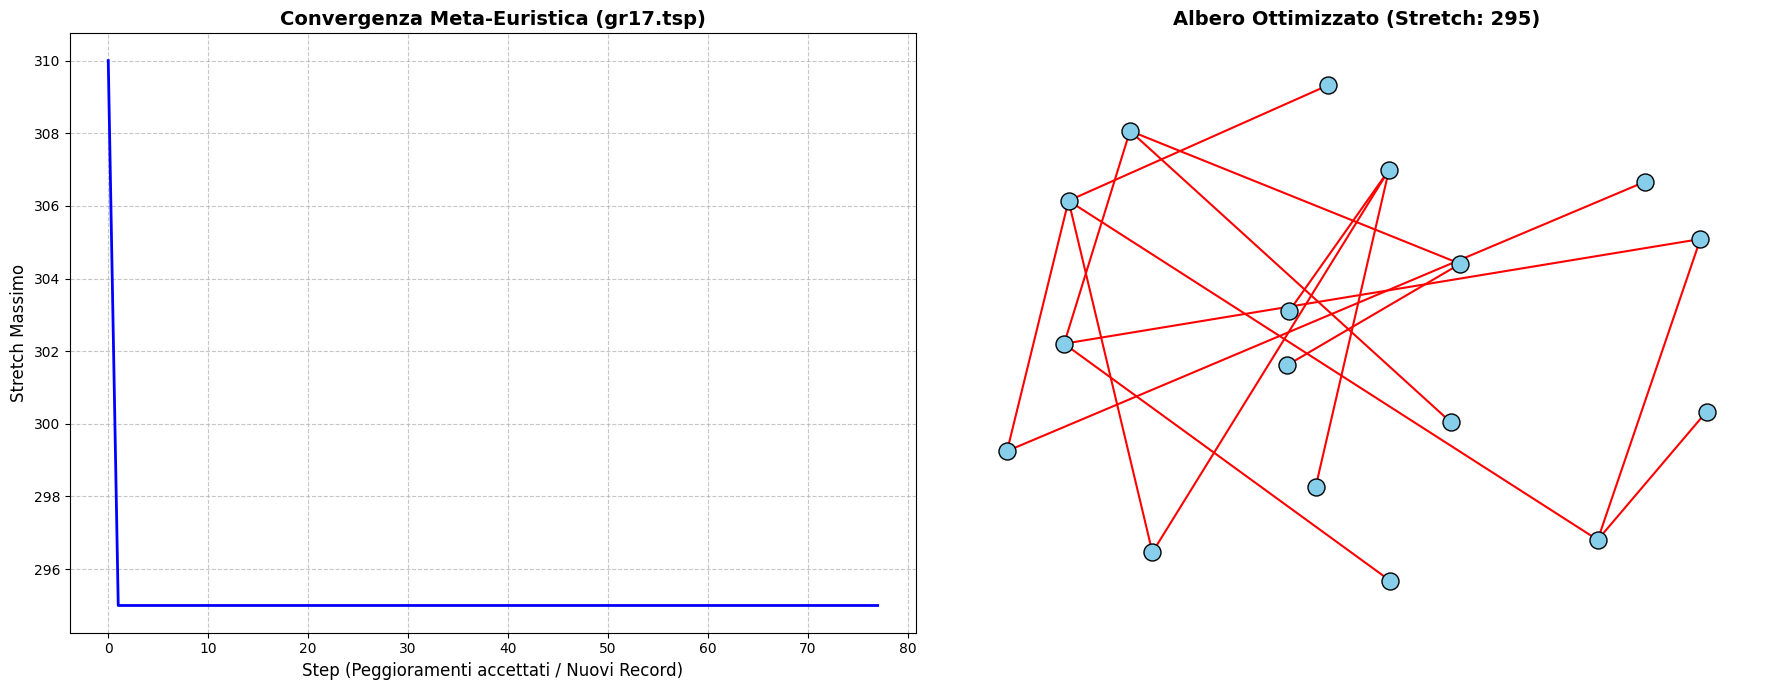

In [ ]:
import time
import matplotlib.pyplot as plt

def run_metaheuristic_test():
    instance_name = 'gr17.tsp'
    path_inst = os.path.join("data", "extracted_tsp", instance_name)
    if not os.path.exists(path_inst):
        print(f"Istanza non trovata: {path_inst}")
        return
        
    G = load_tsp_as_graph(path_inst)
    

    print("1. Generazione Soluzione Iniziale (Random Kruskal)...")
    T_init, stretch_init, _ = generate_initial_solution(G, method='kruskal', rcl_size=3)
    


    print("\n2. Avvio Simulated Annealing con Local Search Ibrida...")
    start_time = time.time()
    
    # Parametri SA configurati per test rapido e interattivo
    T_best, stretch_best, history = simulated_annealing(
        G, T_init, 
        T_high=50.0, # temperatura iniziale (non altissima per evitare di accettare troppi peggioramenti all'inizio)
        T_low=1.0, # temperatura sotto la quale il SA si ferma
        alpha=0.95, # fattore con cui si riduce la temperatura ad ogni ciclo (T = T * alpha)
        max_iters_per_temp=20   # per ogni temperatura vengono eseguite 20 iterazioni
    )
    
    end_time = time.time()
    


    print(f"\n--- RISULTATI FINALI ---")
    print(f"Tempo di esecuzione: {round(end_time - start_time, 2)} secondi")
    print(f"Miglioramento Stretch: da {round(stretch_init, 2)} a {round(stretch_best, 2)}")
    
    # --- GRAFICI ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    # 1. Convergenza
    ax1.plot(history, color='blue', linewidth=2)
    ax1.set_title(f"Convergenza Meta-Euristica ({instance_name})", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Step (Peggioramenti accettati / Nuovi Record)", fontsize=12)
    ax1.set_ylabel("Stretch Massimo", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Visualizzazione Albero Finale (versione leggera)
    ax2.set_title(f"Albero Ottimizzato (Stretch: {round(stretch_best, 2)})", fontsize=14, fontweight='bold')
    node_coords = nx.get_node_attributes(G, 'coord')
    
    # Valida e correggi le coordinate
    pos = validate_and_fix_pos(node_coords if node_coords else {}, G)
    
    nx.draw_networkx_nodes(G, pos, node_color='#87CEEB', node_size=150, edgecolors='black', ax=ax2)
    nx.draw_networkx_edges(T_best, pos, edge_color='red', width=1.5, ax=ax2)
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

# Esecuzione vera e propria della pipeline completa!
run_metaheuristic_test()

## Solver
Cella per generare i file .dat da fornire in input al solver

# OSS DA SCARTARE
Cella che se non modifico nulla è da scartare perchè il file .dat non mi torna utile dato che le istanze sono troppo grandi per il solver Xpress

In [38]:
import tsplib95
import numpy as np
import os

def genera_file_dat_per_xpress(file_tsp, file_output="matrice.dat"):
    # Usa il path completo se il file non è nella working directory
    if not os.path.exists(file_tsp):
        # Prova a cercare nella cartella delle istanze estratte
        file_tsp_alt = os.path.join("data", "extracted_tsp", file_tsp)
        if os.path.exists(file_tsp_alt):
            file_tsp = file_tsp_alt
        else:
            raise FileNotFoundError(f"File {file_tsp} non trovato.")
    
    # Carica l'istanza TSPLIB
    problem = tsplib95.load(file_tsp)
    n_nodi = problem.dimension

    # Crea la matrice dei costi
    matrice_costi = np.zeros((n_nodi, n_nodi))

    # Ottieni la lista esatta dei nodi (può non essere 0-based)
    nodi = list(problem.get_nodes())

    for i in range(n_nodi):
        for j in range(n_nodi):
            if i != j:
                try:
                    peso = problem.get_weight(nodi[i], nodi[j])
                except Exception as e:
                    print(f"Errore nel calcolo del peso tra {nodi[i]} e {nodi[j]}: {e}")
                    peso = 0
                matrice_costi[i][j] = peso

    # Scrivi il file .dat formattato per Mosel
    with open(file_output, 'w') as f:
        f.write(f"N: {n_nodi}\n\n")
        f.write("COST: [\n")
        for riga in matrice_costi:
            riga_str = " ".join(str(int(round(val))) for val in riga)
            f.write(f"  {riga_str}\n")
        f.write("]\n")

    print(f"File {file_output} generato con successo da {file_tsp} ({n_nodi} nodi).")

# --- ESECUZIONE ---
# Cambia qui il nome del file che vuoi testare
genera_file_dat_per_xpress("gr17.tsp", "matrice.dat")
# genera_file_dat_per_xpress("att48.tsp", "matrice.dat")

File matrice.dat generato con successo da data/extracted_tsp/gr17.tsp (17 nodi).
